### **Loan Approval Prediction**

##### **Merishot Internship Task.** This project applies **classification**, using historical datasets gotten from kaggle to predict whether a loan will be approved. Classification is suitable because the target loan variable *(Loan_Status)* is categorical *(Approved/Not Approved)*. The workflow is as follows;
1. Data Loading 
2. Data Overview
3. Data Cleaning
4. Feature Engineering
5. Feature Exploration (EDA) 
6. Data Preprocessing
7. Modelling
8. Prediction
9. Evaluation
10. Insights 

##### Data Loading

In [25]:
# Importing Libaries 
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt   
import seaborn as sns   

In [26]:
# loading the dataset
df = pd.read_csv(r'C:\Users\hp\OneDrive\Documents\projects\merishot internship\task_5\raw data\archive\train_u6lujuX_CVtuZ9i.csv')

##### Data Overview

In [27]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [28]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


(614, 13)

In [29]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [30]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


##### Feature Engineering

In [31]:
# data cleaning
# filling up categorical data
from feature_engine.imputation import CategoricalImputer
cl = CategoricalImputer(imputation_method='frequent',variables=['Gender', 'Married', 'Dependents', 'Self_Employed'])
df = cl.fit_transform(df)

# filling up numerical data 
from feature_engine.imputation import MeanMedianImputer
mn = MeanMedianImputer(imputation_method='median', variables=['LoanAmount','Loan_Amount_Term','Credit_History'])
df = mn.fit_transform(df)

In [32]:
df = df.drop(columns="Loan_ID")
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [33]:
df.head(10)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [34]:
df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = df['Dependents'].astype(float)

In [35]:
# encoding texts to numbers using label encoding
from feature_engine.encoding import OrdinalEncoder
oe = OrdinalEncoder(encoding_method='arbitrary', variables=['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status'])
df = oe.fit_transform(df)

In [36]:
df.head(10)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,0,0.0,0,0,5849,0.0,128.0,360.0,1.0,0,0
1,0,1,1.0,0,0,4583,1508.0,128.0,360.0,1.0,1,1
2,0,1,0.0,0,1,3000,0.0,66.0,360.0,1.0,0,0
3,0,1,0.0,1,0,2583,2358.0,120.0,360.0,1.0,0,0
4,0,0,0.0,0,0,6000,0.0,141.0,360.0,1.0,0,0
5,0,1,2.0,0,1,5417,4196.0,267.0,360.0,1.0,0,0
6,0,1,0.0,1,0,2333,1516.0,95.0,360.0,1.0,0,0
7,0,1,3.0,0,0,3036,2504.0,158.0,360.0,0.0,2,1
8,0,1,2.0,0,0,4006,1526.0,168.0,360.0,1.0,0,0
9,0,1,1.0,0,0,12841,10968.0,349.0,360.0,1.0,2,1


In [37]:
oe.encoder_dict_

{'Gender': {'Male': 0, 'Female': 1},
 'Married': {'No': 0, 'Yes': 1},
 'Education': {'Graduate': 0, 'Not Graduate': 1},
 'Self_Employed': {'No': 0, 'Yes': 1},
 'Property_Area': {'Urban': 0, 'Rural': 1, 'Semiurban': 2},
 'Loan_Status': {'Y': 0, 'N': 1}}

#### Feature Exploration *(EDA)*

In [38]:
df.describe()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.182410,0.653094,0.744300,0.218241,0.133550,5403.459283,1621.245798,145.752443,342.410423,0.855049,1.050489,0.312704
std,0.386497,0.476373,1.009623,0.413389,0.340446,6109.041673,2926.248369,84.107233,64.428629,0.352339,0.840875,0.463973
min,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,2877.500000,0.000000,100.250000,360.000000,1.000000,0.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,3812.500000,1188.500000,128.000000,360.000000,1.000000,1.000000,0.000000
75%,0.000000,1.000000,1.000000,0.000000,0.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000,2.000000,1.000000
max,1.000000,1.000000,3.000000,1.000000,1.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000,2.000000,1.000000


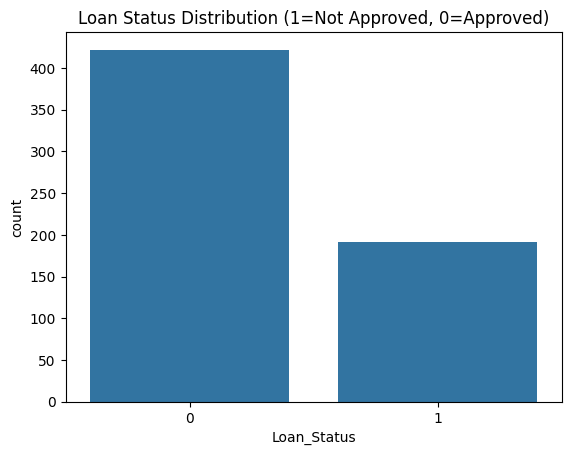

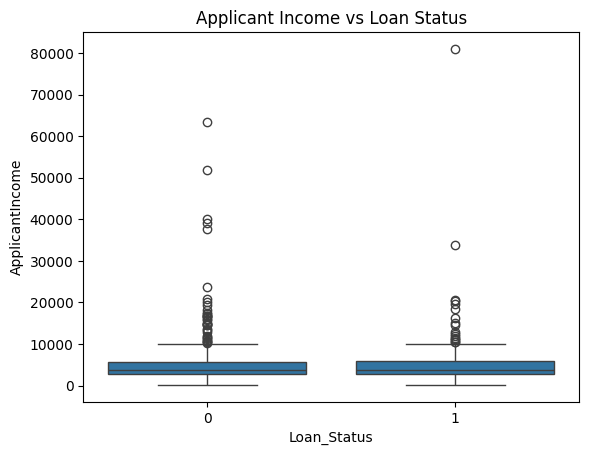

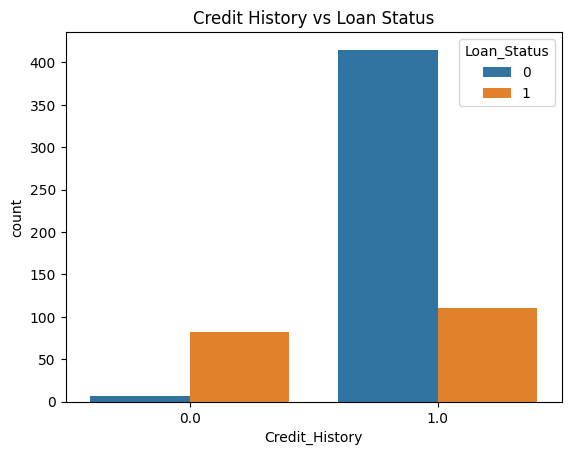

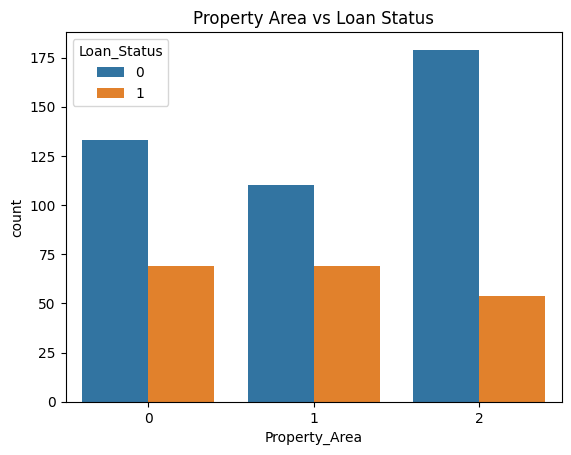

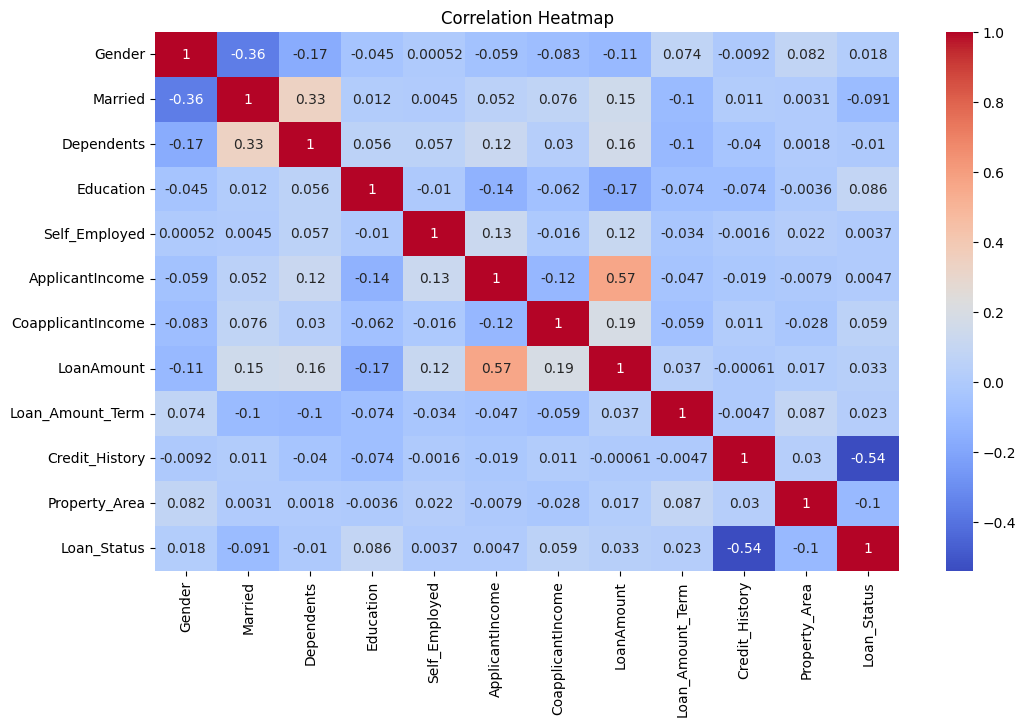

In [39]:

# Loan Status distribution
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Status Distribution (1=Not Approved, 0=Approved)")
plt.show()

# Applicant Income vs Loan Status
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title("Applicant Income vs Loan Status")
plt.show()

# Credit History vs Loan Status
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Credit History vs Loan Status")
plt.show()

# Property Area vs Loan Status
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)
plt.title("Property Area vs Loan Status")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

##### Description of plot 
1. loan status distrubution: The target variable shows more loans are approved (0) than not approved (1). Which indicates a slight imbalance reflecting on real world patterns.
2. Applicants with higher incomes tend to have a higher loan approval rates, although income does not determine loan approval decisions.
3. Credit history shows strong relationship with loan approval, where applicants with good credit history are significantly likely to have their loans approved.
4. Loan approvals are more frequent in semi urban and urban prorerty areas, which suggests that location plays a role in the approval decision process.
5. The correlation heatmap reveals that credit history has the strongest relationship with loan approval, while other numerical features shows weaker correlations, which indicates multiply factors jointly influence loan decisions.

##### Data Preprocessing

In [40]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [41]:
# feature selection 
from sklearn.feature_selection import SelectKBest, chi2
chi2_selector = SelectKBest(score_func=chi2, k=9)
x_selected = chi2_selector.fit_transform(X,y)
print("selected features (chi_squared):")
print(X.columns[chi2_selector.get_support()])

selected features (chi_squared):
Index(['Gender', 'Married', 'Education', 'ApplicantIncome',
       'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History',
       'Property_Area'],
      dtype='object')


In [42]:
# spliting the data into training and test (80/20)
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(
    x_selected, y, test_size=0.2, random_state=42
)


#### Modelling

In [43]:
# trying logistic regression 
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(solver='liblinear')
lr.fit(X_train, y_train)
pred = lr.predict(X_test)

In [44]:
# trying random forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=10)
rf.fit(X_train, y_train)
pred1 = rf.predict(X_test)


#### Evaluation

In [45]:
# checking accuracy for logistic regression
from sklearn.metrics import accuracy_score
accuracy_score(pred, y_test)

0.7886178861788617

In [46]:
# checing classification report for logistic regression
from sklearn.metrics import classification_report
print(classification_report(y_test, pred, target_names=('Not_Approved', 'Approved',)))

              precision    recall  f1-score   support

Not_Approved       0.76      0.99      0.86        80
    Approved       0.95      0.42      0.58        43

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [47]:
# checking accuracy for random forest
accuracy_score(pred1, y_test)


0.7886178861788617

In [48]:
# checking classification report for random forest
print(classification_report(y_test, pred1, target_names=('Not_Approved', 'Approved',)))

              precision    recall  f1-score   support

Not_Approved       0.76      0.99      0.86        80
    Approved       0.95      0.42      0.58        43

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



##### Insights

* Credit history is the strongest factor influencing loan approval
* Higher income increases approval chances but does not guarantee approval
* Property area affects approval trends, with semi-urban and urban areas showing higher approval rates
* Loan approval decisions depend on multiple factors, not a single feature
* Random Forest outperformed Logistic Regression, while Logistic Regression remained useful for explainability